Failed to render LaTeX: 
tf_{idf}(chunk,term)=\frac{count(term,chunk)/\sum_{term}count(term,chunk)}{log(count(chunk)/count(chunk|term\inchunk))}
                                                                                                            ^
ParseSyntaxException: Unknown symbol: \inchunk, found '\'  (at char 108), (line:1, col:109)
Failed to render LaTeX: 
D_{KL}(P∥Q)=\sumP(x)log\frac{P(x)}{Q(x)}=\underset{\text{Entropy}\;\text{of}\;P}{\underset{︸}{\sumP(x)log(P(x))}}-\underset{\text{Cross-entropy}}{\underset{︸}{\sumP(x)log(Q(x))}}
            ^
ParseFatalException: Unknown symbol: \sumP, found '\'  (at char 12), (line:1, col:13)



Figure: Figure 1-1
Alt:    A pencil sketch in the style of Degas shows a family of four playing a board game, illustrating the potential challenges in model-generated art regarding symmetry and detail accuracy.
Caption: Sending a prompt to a foundational model to get back a response


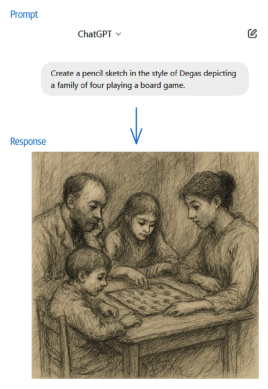

In [11]:
# Estraiamo la prima immagine dal libro di test
from pathlib import Path
import sys
sys.path.insert(0, str(Path().resolve().parent))  # se il notebook è in experiments/

import tempfile
from pipeline.extractor import Figure, extract_chapters
from matplotlib import pyplot as plt
%matplotlib inline

with tempfile.TemporaryDirectory() as tmp:
    chapters = extract_chapters(Path("../book.epub"), Path(tmp))
    figure = chapters[0].figures[0]
    
    # Per l'immagine vera (non quella temp), usa il PNG già scritto in output/audiobook/assets
    # OPPURE fai una copia dell'immagine dal tmp prima che venga distrutto
    import shutil
    persistent_path = Path("datapizza_test_assets/test_image.png")
    persistent_path.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy(figure.rendered_path, persistent_path)
    
    # Ricostruisci una Figure con il path persistente
    figure = Figure(
        number=figure.number,
        context=figure.context,
        dom_position=figure.dom_position,
        narration="",
        rendered_path=persistent_path,
        label=figure.label,
        alt=figure.alt,
        caption=figure.caption,
    )

print()
print(f"Figure: {figure.label}")
print(f"Alt:    {figure.alt}")
print(f"Caption: {figure.caption}")

img = plt.imread(figure.rendered_path)
plt.imshow(img)
plt.axis('off')
plt.show()

In [14]:
# costruiamo i prompt per l'AI
system_prompt = "You are narrating a technical book. Based on the caption/alt text and " \
            "section context, generate a 1-2 sentence audio description of what " \
            "this figure likely shows. Be concise."

prompt = (
            f"Describe this figure for an audio listener:\n"
            f"Label: {figure.label}\n"
            f"Alt text: {figure.alt}\n"
            f"Caption: {figure.caption}\n"
            f"Section: {figure.context}"
        )

print("System prompt:")
print(system_prompt)
print("\nUser prompt:")
print(prompt)

System prompt:
You are narrating a technical book. Based on the caption/alt text and section context, generate a 1-2 sentence audio description of what this figure likely shows. Be concise.

User prompt:
Describe this figure for an audio listener:
Label: Figure 1-1
Alt text: A pencil sketch in the style of Degas shows a family of four playing a board game, illustrating the potential challenges in model-generated art regarding symmetry and detail accuracy.
Caption: Sending a prompt to a foundational model to get back a response
Section: Prompt and Context


In [15]:
# ci colleghiamo con il client ollama per le task testuali

from datapizza.clients.openai_like import OpenAILikeClient

client = OpenAILikeClient(
    api_key="",                         # non serve per Ollama, ma è richiesto per l'inizializzazione del client
    model="qwen3:8b",                   # specifica il modello da utilizzare, ad esempio "gpt-4" o "gpt-3.5-turbo"
    system_prompt=system_prompt,
    base_url="http://localhost:11434/v1"   # URL di Ollama
)

response_a = client.invoke(prompt)
print(response_a.text)

The figure depicts a Degas-inspired pencil sketch of a family playing a board game, highlighting challenges in model-generated art such as asymmetry and detail inaccuracies when responding to textual prompts.


In [ ]:
# ci colleghiamo con il client per le task visive
from datapizza.clients.openai_like import OpenAILikeClient
from datapizza.type import Media, MediaBlock, TextBlock

# per la chiave API
import os
from dotenv import load_dotenv
load_dotenv()
api_key = os.getenv("OPENROUTER_API_KEY")
print(f"OPENROUTER_API_KEY: {api_key[:4]}...{api_key[-4:]}")  # Print only the first and last 4 characters for security 


# Create image media object
image = Media(
    media_type="image",
    source_type="path",
    source=str(figure.rendered_path),  # questo mi serve per fare in modo che il path venga codificato per il salvataggio in cache (Path object non serializzabile)
    extension="png"
)

# Create media block
media_block = MediaBlock(media=image)
text_block = TextBlock(content=prompt)

client = OpenAILikeClient(
    api_key=api_key,     # OpenRouter API key
    model="google/gemini-2.5-flash",                  
    system_prompt=system_prompt,
    base_url="https://openrouter.ai/api/v1"   # URL di OpenRouter
)

response_b = client.invoke(
    input=[text_block, media_block],
    max_tokens=500
)
print(response_b.text)

# altro test, togliamo il testo e vediamo se riesce a descrivere solo con l'immagine
text_block_empty = TextBlock(content="Describe this figure for an audio listener:")  # blocco di testo vuoto

response_c = client.invoke(
    input=[text_block_empty, media_block],
    max_tokens=500
)
print(response_c.text)

OPENROUTER_API_KEY: sk-o...1e61
This figure illustrates a prompt sent to a foundational model, prompting a pencil sketch of a family playing a board game in the style of Degas. The resulting image effectively demonstrates how model-generated art may encounter challenges in maintaining symmetry and intricate detail.
This figure illustrates a prompt and response from ChatGPT. ChatGPT was prompted to "Create a pencil sketch in the style of Degas depicting a family of four playing a board game," and the response is a detailed sketch showing a family of four around a table playing a board game.


In [30]:
# confronto tra i due risultati
print("Response from Ollama (text-only):")
print(response_a.text)
print("\nResponse from OpenRouter (multimodal):")
print(response_b.text)
print("\nResponse from OpenRouter (image-only):")
print(response_c.text)

Response from Ollama (text-only):
The figure depicts a Degas-inspired pencil sketch of a family playing a board game, highlighting challenges in model-generated art such as asymmetry and detail inaccuracies when responding to textual prompts.

Response from OpenRouter (multimodal):
This figure illustrates a prompt sent to a foundational model, prompting a pencil sketch of a family playing a board game in the style of Degas. The resulting image effectively demonstrates how model-generated art may encounter challenges in maintaining symmetry and intricate detail.

Response from OpenRouter (image-only):
This figure illustrates a prompt and response from ChatGPT. ChatGPT was prompted to "Create a pencil sketch in the style of Degas depicting a family of four playing a board game," and the response is a detailed sketch showing a family of four around a table playing a board game.


In [31]:
# cache
from datapizza.core.cache import MemoryCache

# instanziamo due cache separate, una per Ollama e una per OpenRouter
cache_ollama = MemoryCache()
cache_openrouter = MemoryCache()

client_ollama = OpenAILikeClient(
    api_key="",
    model="qwen3:8b",                  
    system_prompt=system_prompt,
    base_url="http://localhost:11434/v1",   # URL di Ollama
    cache=cache_ollama
)

client_openrouter = OpenAILikeClient(
    api_key=api_key,     # OpenRouter API key
    model="google/gemini-2.5-flash",                  
    system_prompt=system_prompt,
    base_url="https://openrouter.ai/api/v1" ,  # URL di OpenRouter
    cache=cache_openrouter
)

print(f"Cache with Ollama: {client_ollama.cache}")  # dovrebbe essere vuota
print(f"Cache with OpenRouter: {client_openrouter.cache}")  # dovrebbe essere vuota

Cache with Ollama: <datapizza.core.cache.cache.MemoryCache object at 0x7ab543ecd820>
Cache with OpenRouter: <datapizza.core.cache.cache.MemoryCache object at 0x7ab5486e8f50>


In [32]:
# cache test per Ollama
import time
t0 = time.time()
r1 = client_ollama.invoke(input=prompt, max_tokens=500)
t1 = time.time()
print(f"First call: {t1 - t0:.2f}s")

t0 = time.time()
r2 = client_ollama.invoke(input=prompt, max_tokens=500)
t1 = time.time()
print(f"Second call (should be cached): {t1 - t0:.2f}s")

# cache test per OpenRouter
t0 = time.time()
r3 = client_openrouter.invoke(input=[text_block, media_block], max_tokens=500)
t1 = time.time()
print(f"First call: {t1 - t0:.2f}s")    

t0 = time.time()
r4 = client_openrouter.invoke(input=[text_block, media_block], max_tokens=500)
t1 = time.time()
print(f"Second call (should be cached): {t1 - t0:.2f}s")


First call: 5.17s
INFO     [2026-05-03 20:03:36 - datapizza.core.cache.cache:73] Cache hit for 1ac8f4e9241037aa5204c24f7cb5f7094ebf29d7f4ae521bda7940a4abef1557
Second call (should be cached): 0.00s
First call: 2.08s
INFO     [2026-05-03 20:03:38 - datapizza.core.cache.cache:73] Cache hit for 152335db36dba0183158d41e3d41470ff813de30caa77a0ed33914b8d2a9c00a
Second call (should be cached): 0.00s


In [33]:
# tracing test
from datapizza.tracing import ContextTracing

with ContextTracing().trace("test_text_only"):
       r1 = client_ollama.invoke(input=prompt, max_tokens=500)
       r2 = client_ollama.invoke(input="questo è un test", max_tokens=100)  # dovrebbe essere cached

with ContextTracing().trace("test_multi_provider"):
    r_text = client_ollama.invoke(input="Cosa è RAG?", max_tokens=200)
    
    text_block = TextBlock(content="Describe this image in one sentence.")
    media_block = MediaBlock(media=Media(
        media_type="image",
        source_type="path",
        source=str(figure.rendered_path),
        extension="png",
    ))
    r_vision = client_openrouter.invoke(input=[text_block, media_block], max_tokens=200)

INFO     [2026-05-03 20:08:09 - datapizza.core.cache.cache:73] Cache hit for 1ac8f4e9241037aa5204c24f7cb5f7094ebf29d7f4ae521bda7940a4abef1557


╭──────────────────────────────────────── Trace Summary of test_text_only ────────────────────────────────────────╮
│ Total Spans: 2                                                                                                  │
│ Duration: 5.23s                                                                                                 │
│                                    Token Usage                                                                  │
│ ┏━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓                              │
│ ┃ Model    ┃ Prompt Tokens ┃ Completion Tokens ┃ Cached Tokens ┃ Thinking Tokens ┃                              │
│ ┡━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩                              │
│ │ qwen3:8b │ 58            │ 234               │ 0             │ 0               │                              │
│ └──────────┴───────────────┴───────────────────┴───────────────┴─────────────────┘                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────── Trace Summary of test_multi_provider ──────────────────────────────────────╮
│ Total Spans: 3                                                                                                  │
│ Duration: 6.19s                                                                                                 │
│                                            Token Usage                                                          │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓               │
│ ┃ Model                   ┃ Prompt Tokens ┃ Completion Tokens ┃ Cached Tokens ┃ Thinking Tokens ┃               │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩               │
│ │ qwen3:8b                │ 59            │ 250               │ 0             │ 0               │               │
│ │ google/gemini-2.5-flash │ 1851          │ 59                │ 0             │ 0               │               │
│ └─────────────────────────┴───────────────┴───────────────────┴───────────────┴─────────────────┘               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [34]:
# Controlliamo che la risposta sia serializzabile in JSON (per verificare che non contenga elementi non serializzabili come Path o simili)
import json
r1 = client_ollama.invoke(input="test")
print(type(r1))
print(r1.model_dump() if hasattr(r1, "model_dump") else r1)
print(json.dumps(r1.model_dump(), default=str)[:500])  # se passa, FileCache è OK

<class 'datapizza.core.clients.models.ClientResponse'>
ClientResponse(content=[TextBlock(content=Please provide the caption/alt text or section context so I can generate an accurate audio description for the figure. Without specific details, I cannot assume the content of the visual.)], delta=None, stop_reason=stop)


AttributeError: 'ClientResponse' object has no attribute 'model_dump'

In [35]:
from datapizza.core.clients.models import ClientResponse
from datapizza.type import TextBlock
r = ClientResponse(content=[TextBlock(content="hello")], delta=None, stop_reason="stop")
print(r.text)  # → "hello" ?

hello


In [36]:
from pathlib import Path
from pipeline.file_cache import FileCache
from datapizza.clients.openai_like import OpenAILikeClient

cache = FileCache(Path(".test_cache"))
client = OpenAILikeClient(
    api_key="ollama",
    model="qwen3:8b",
    base_url="http://localhost:11434/v1",
    cache=cache,
)

r1 = client.invoke(input="What is RAG?", max_tokens=100)
print("First:", r1.text[:80])

# Stessa chiamata, diverso processo: nuova istanza FileCache che legge da disco
cache2 = FileCache(Path(".test_cache"))
client2 = OpenAILikeClient(
    api_key="ollama",
    model="qwen3:8b",
    base_url="http://localhost:11434/v1",
    cache=cache2,
)

r2 = client2.invoke(input="What is RAG?", max_tokens=100)
print("Second (from disk):", r2.text[:80])

First: **Retrieval-Augmented Generation (RAG)** is a technique that combines **retrieva
INFO     [2026-05-03 23:41:25 - datapizza.core.cache.cache:73] Cache hit for 7e1b1cde5e1fed3ef943eb04b1f5938480807b4992805d6833ff41e351f41481
Second (from disk): **Retrieval-Augmented Generation (RAG)** is a technique that combines **retrieva
